## Week 6: Dataset Exploration (NSL-KDD)
Loading the dataset, checking data quality, and studying the class distribution.

In [2]:
%pip install pandas numpy scikit-learn imbalanced-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas, sklearn, imblearn
print("Ready", sklearn.__version__)

Ready 1.9.1


In [5]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

FEATURES = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
 "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations",
 "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count","serror_rate",
 "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
 "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
 "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate"]
COLS = FEATURES + ["label", "difficulty"]
URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/"

train = pd.read_csv("KDDTrain+.txt", names=COLS)
test  = pd.read_csv("KDDTest+.txt",  names=COLS)
print("Train:", train.shape, "| Test:", test.shape)
train.head()

Train: (125973, 43) | Test: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [6]:
print("Missing values :", train.isnull().sum().sum())
print("Duplicate rows :", train.duplicated().sum())
print("Protocols:", train.protocol_type.nunique(), "| Services:", train.service.nunique(), "| Flags:", train.flag.nunique())
print("Attack types in train:", train.label.nunique() - 1, "| in test:", test.label.nunique() - 1)
print("Attacks only in test:", sorted(set(test.label) - set(train.label)))

Missing values : 0
Duplicate rows : 0
Protocols: 3 | Services: 70 | Flags: 11
Attack types in train: 22 | in test: 37
Attacks only in test: ['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


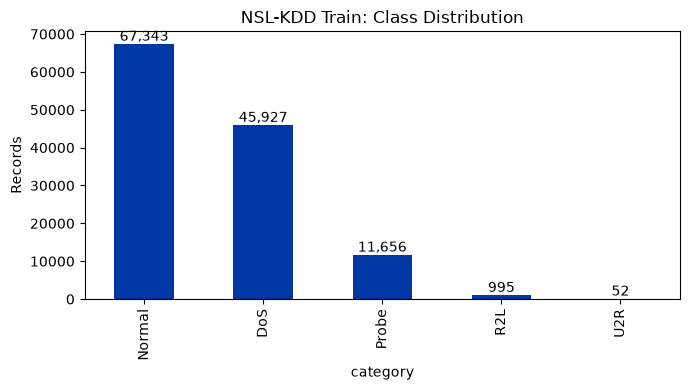

In [7]:
DOS   = ["back","land","neptune","pod","smurf","teardrop","apache2","mailbomb","processtable","udpstorm"]
PROBE = ["ipsweep","nmap","portsweep","satan","mscan","saint"]
R2L   = ["ftp_write","guess_passwd","imap","multihop","phf","spy","warezclient","warezmaster","sendmail","named",
         "snmpgetattack","snmpguess","xlock","xsnoop","worm"]
U2R   = ["buffer_overflow","loadmodule","perl","rootkit","httptunnel","ps","sqlattack","xterm"]

def category(l):
    if l == "normal": return "Normal"
    if l in DOS: return "DoS"
    if l in PROBE: return "Probe"
    if l in R2L: return "R2L"
    if l in U2R: return "U2R"

for df in (train, test):
    df["category"] = df.label.apply(category)

counts = train.category.value_counts()
print(counts)
ax = counts.plot(kind="bar", color="#0037A4", title="NSL-KDD Train: Class Distribution", figsize=(7,4))
for i, v in enumerate(counts.values): ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.ylabel("Records"); plt.tight_layout()
plt.savefig("eda_class_distribution.png", dpi=150); plt.show()

## Week 7: Preprocessing, Feature Engineering & Baseline Model
Cleaning, feature engineering, encoding, feature selection, class balancing (ADASYN) and Random Forest training.

In [8]:
before = len(train)
train = train.drop_duplicates()
print("Duplicates removed:", before - len(train))

num_cols = train[FEATURES].select_dtypes(include=np.number).columns
constant = [c for c in num_cols if train[c].nunique() <= 1]
print("Constant columns dropped:", constant)
train = train.drop(columns=constant); test = test.drop(columns=constant)

Duplicates removed: 0
Constant columns dropped: ['num_outbound_cmds']


In [9]:
def engineer(df):
    df = df.copy()
    df["log_src_bytes"] = np.log1p(df.src_bytes)                 # bytes ki range bahut badi hai, log se chhoti hoti hai
    df["log_dst_bytes"] = np.log1p(df.dst_bytes)
    df["bytes_ratio"] = df.src_bytes / (df.dst_bytes + 1)         # bheja vs aaya data
    df["total_error_rate"] = df.serror_rate + df.rerror_rate      # DoS / scan ki pehchaan
    df["privilege_activity"] = df.root_shell + df.su_attempted + df.num_root + df.num_shells  # U2R / R2L
    return df.drop(columns=["src_bytes", "dst_bytes"])

train_fe, test_fe = engineer(train), engineer(test)
print("New features added:", ["log_src_bytes","log_dst_bytes","bytes_ratio","total_error_rate","privilege_activity"])

New features added: ['log_src_bytes', 'log_dst_bytes', 'bytes_ratio', 'total_error_rate', 'privilege_activity']


In [10]:
from sklearn.preprocessing import MinMaxScaler

CAT = ["protocol_type", "service", "flag"]
DROP = ["label", "difficulty", "category"]
X_train = pd.get_dummies(train_fe.drop(columns=DROP), columns=CAT)
X_test  = pd.get_dummies(test_fe.drop(columns=DROP), columns=CAT)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

scaler = MinMaxScaler().fit(X_train)                  # sirf train pe fit, isliye data leakage nahi
X_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),  columns=X_train.columns)
y_train, y_test = train_fe.category.values, test_fe.category.values
print("Features after encoding:", X_train.shape[1])

Features after encoding: 124


Highly correlated features removed: 9
Selected features: 40


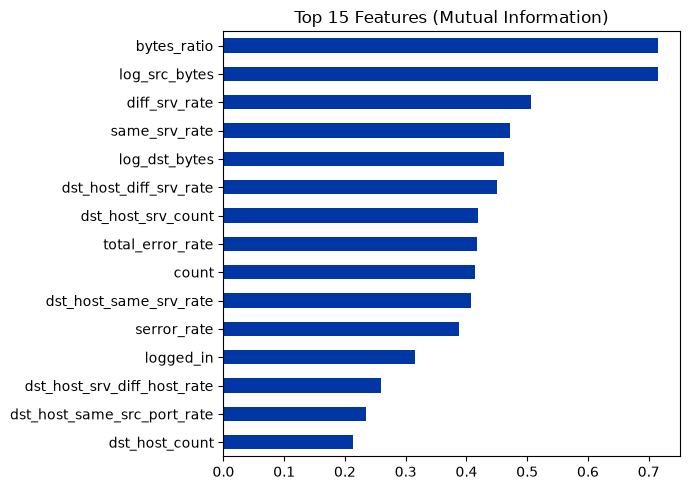

In [11]:
from sklearn.feature_selection import mutual_info_classif

corr = X_train.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [c for c in upper.columns if (upper[c] > 0.95).any()]
X_train = X_train.drop(columns=high_corr); X_test = X_test.drop(columns=high_corr)
print("Highly correlated features removed:", len(high_corr))

mi = pd.Series(mutual_info_classif(X_train, y_train, random_state=42), index=X_train.columns).sort_values(ascending=False)
selected = mi.head(40).index
X_train, X_test = X_train[selected], X_test[selected]
print("Selected features:", len(selected))

mi.head(15).sort_values().plot(kind="barh", figsize=(7,5), color="#0037A4", title="Top 15 Features (Mutual Information)")
plt.tight_layout(); plt.savefig("feature_importance_mi.png", dpi=150); plt.show()

In [12]:
from imblearn.over_sampling import ADASYN

print("Before:", pd.Series(y_train).value_counts().to_dict())
X_bal, y_bal = ADASYN(random_state=42, n_neighbors=5).fit_resample(X_train, y_train)
print("After :", pd.Series(y_bal).value_counts().to_dict())

Before: {'Normal': 67343, 'DoS': 45927, 'Probe': 11656, 'R2L': 995, 'U2R': 52}
After : {'Probe': 67372, 'DoS': 67362, 'U2R': 67350, 'R2L': 67348, 'Normal': 67343}


Accuracy : 74.9 %
Macro F1 : 51.66 %
              precision    recall  f1-score   support

         DoS      0.949     0.764     0.846      7458
      Normal      0.649     0.973     0.778      9711
       Probe      0.877     0.648     0.745      2421
         R2L      0.937     0.060     0.112      2754
         U2R      0.611     0.055     0.101       200

    accuracy                          0.749     22544
   macro avg      0.805     0.500     0.517     22544
weighted avg      0.807     0.749     0.710     22544



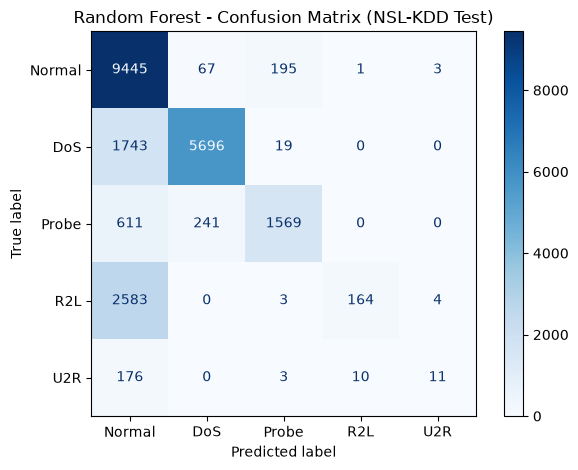

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_bal, y_bal)
pred = rf.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, pred)*100, 2), "%")
print("Macro F1 :", round(f1_score(y_test, pred, average="macro")*100, 2), "%")
print(classification_report(y_test, pred, digits=3))

labels = ["Normal","DoS","Probe","R2L","U2R"]
ConfusionMatrixDisplay(confusion_matrix(y_test, pred, labels=labels), display_labels=labels).plot(cmap="Blues", values_format="d")
plt.title("Random Forest - Confusion Matrix (NSL-KDD Test)")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150); plt.show()